In [1]:
import gdown
import numpy as np
import pandas as pd
from darts import TimeSeries
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose

from sklearn.metrics import mean_squared_error
from scipy.stats import boxcox


from darts.utils.statistics import plot_acf, plot_pacf, acf, pacf

import warnings
warnings.filterwarnings('ignore')
warnings.warn('DelftStack')
warnings.warn('Do not show this message')

In [2]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [3]:
from utils.paths import DATA_RAW_DIR

In [6]:
# Descarga directa de la base de datos
file_id = "1g-X07pjlSiAn2jeYCOD3lWs5_RMQsO9U"
gdown.download(f"https://drive.google.com/uc?id={file_id}", output=str(DATA_RAW_DIR / "w2_icap_90_24.txt"), quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1g-X07pjlSiAn2jeYCOD3lWs5_RMQsO9U
To: /Users/jasonssdev/Dev/Learning/UC/mcd-time-series/data/raw/w2_icap_90_24.txt
100%|██████████| 3.29k/3.29k [00:00<00:00, 38.0kB/s]


'/Users/jasonssdev/Dev/Learning/UC/mcd-time-series/data/raw/w2_icap_90_24.txt'

In [7]:
df = pd.read_table(filepath_or_buffer=str(DATA_RAW_DIR / 'w2_icap_90_24.txt'), header = None, decimal=',')
df.columns = ['icap']
display(df.head(6))
df.info()

  0%|          | 0.00/3.29k [02:25<?, ?B/s]


,icap
0,102.45
1,96.72
2,106.45
3,103.26
4,100.50
5,96.01


<class 'pandas.DataFrame'>
RangeIndex: 412 entries, 0 to 411
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   icap    412 non-null    float64
dtypes: float64(1)
memory usage: 3.3 KB


In [8]:
# MS: Inicio de mes, M: final del mes, D: diaria, H: por hora
df['fecha'] = pd.date_range(start='1990-01', end='2024-04', freq='MS')
df.set_index('fecha', inplace=True)
df.index = pd.to_datetime(df.index)
display(df.head(10))
df_series = TimeSeries.from_series(df['icap'])
display(df_series.head(10))
df_train, df_val = df_series.split_before(pd.Timestamp('2023-10'))

,icap
fecha,
1990-01-01,102.45
1990-02-01,96.72
1990-03-01,106.45
1990-04-01,103.26
1990-05-01,100.50
1990-06-01,96.01
1990-07-01,90.98
1990-08-01,98.82
1990-09-01,101.21


,icap
fecha,
1990-01-01,102.45
1990-02-01,96.72
1990-03-01,106.45
1990-04-01,103.26
1990-05-01,100.50
1990-06-01,96.01
1990-07-01,90.98
1990-08-01,98.82
1990-09-01,101.21


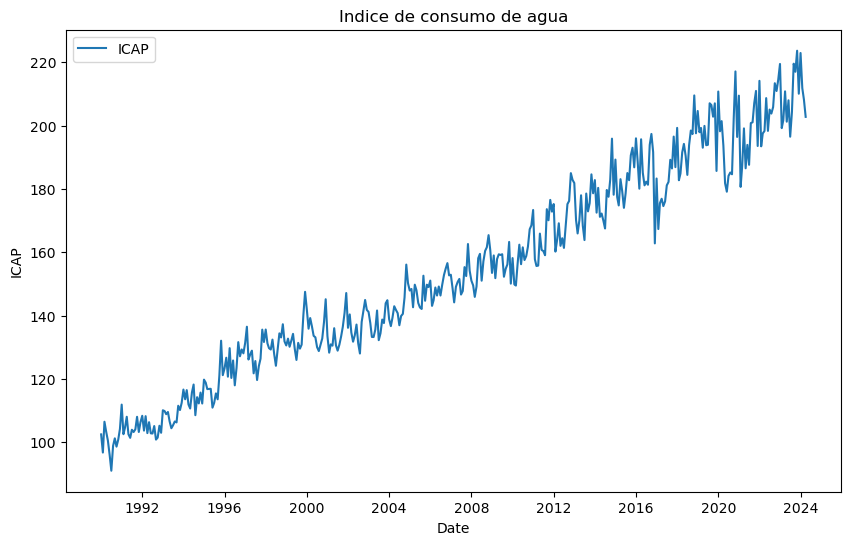

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(df.index, df['icap'], label='ICAP')
plt.title('Indice de consumo de agua')
plt.xlabel('Date')
plt.ylabel('ICAP')
plt.legend()
plt.show()

In [10]:
# Aplicar transformación Box-Cox
df['icap_boxcox'], lmbda = boxcox(df['icap'])
print(f'El valor de lambda es: {lmbda:.2f}')
df.head(10)

El valor de lambda es: 0.43


,icap,icap_boxcox
fecha,,
1990-01-01,102.45,14.826797
1990-02-01,96.72,14.405126
1990-03-01,106.45,15.113282
1990-04-01,103.26,14.885315
1990-05-01,100.50,14.684834
1990-06-01,96.01,14.351900
1990-07-01,90.98,13.968261
1990-08-01,98.82,14.561269
1990-09-01,101.21,14.736702


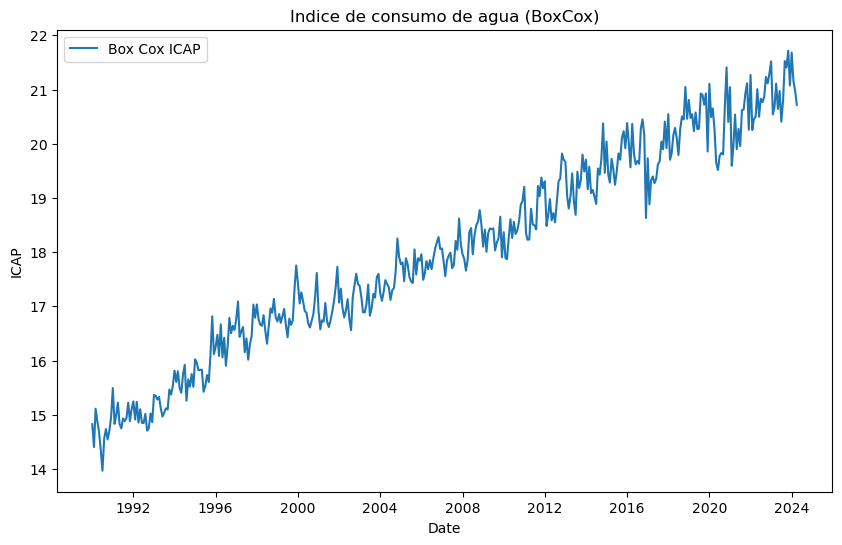

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(df.index, df['icap_boxcox'], label='Box Cox ICAP')
plt.title('Indice de consumo de agua (BoxCox)')
plt.xlabel('Date')
plt.ylabel('ICAP')
plt.legend()
plt.show()

In [12]:
df['icap_diff'] = df['icap'].diff().dropna()
df.head(10)

,icap,icap_boxcox,icap_diff
fecha,,,
1990-01-01,102.45,14.826797,NaN
1990-02-01,96.72,14.405126,-5.73
1990-03-01,106.45,15.113282,9.73
1990-04-01,103.26,14.885315,-3.19
1990-05-01,100.50,14.684834,-2.76
1990-06-01,96.01,14.351900,-4.49
1990-07-01,90.98,13.968261,-5.03
1990-08-01,98.82,14.561269,7.84
1990-09-01,101.21,14.736702,2.39


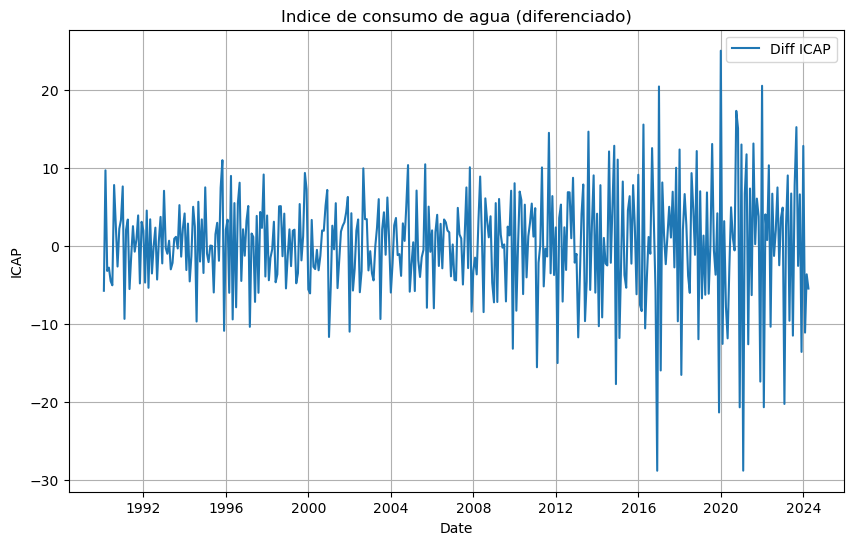

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(df.index, df['icap_diff'], label='Diff ICAP')
plt.title('Indice de consumo de agua (diferenciado)')
plt.xlabel('Date')
plt.ylabel('ICAP')
plt.legend()
plt.grid(True)
plt.show()

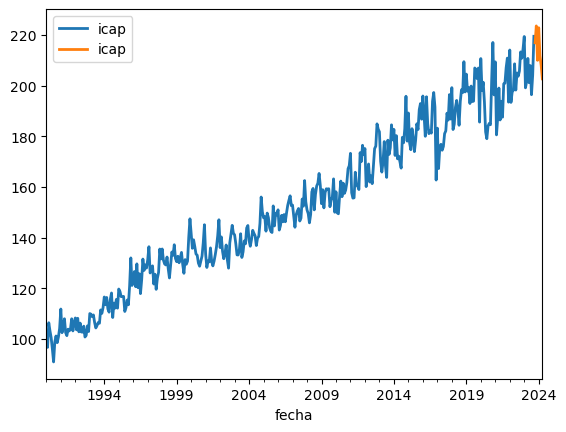

In [14]:
df_train.plot()
df_val.plot()
plt.show()

In [15]:
train_data_np = df_train.values().squeeze()
train_data = pd.DataFrame(train_data_np)
model = ExponentialSmoothing(train_data, trend = 'add', seasonal=None)
result = model.fit()
alpha = result.params['smoothing_level']
beta = result.params['smoothing_trend']

In [16]:
print(f'El valor de alpha es: {alpha:.4f}')
print(f'El valor de beta es: {beta:.4f}')

El valor de alpha es: 0.3346
El valor de beta es: 0.0000


In [17]:
beta

np.float64(0.0)

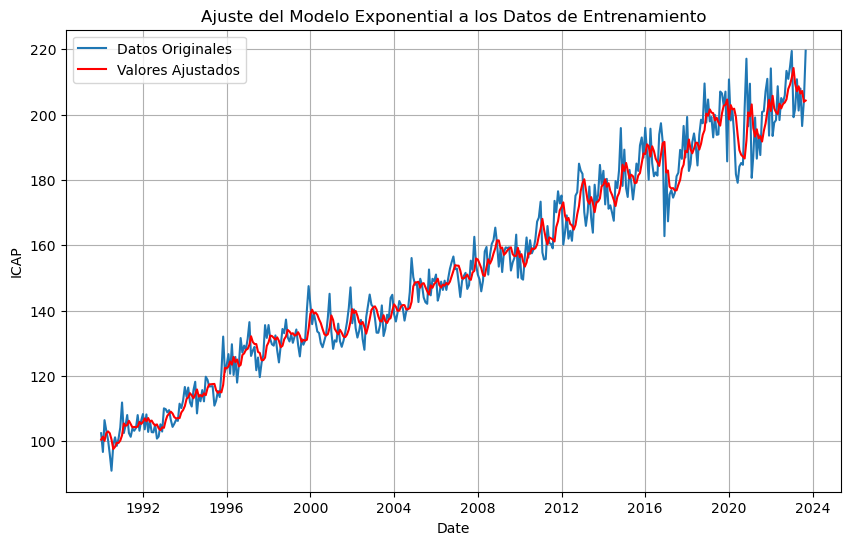

In [18]:
plt.figure(figsize=(10, 6))
plt.plot(df.index[0:405], df['icap'][0:405], label='Datos Originales')
plt.plot(df.index[0:405], result.fittedvalues, label='Valores Ajustados', color='red')
plt.title('Ajuste del Modelo Exponential a los Datos de Entrenamiento')
plt.xlabel('Date')
plt.ylabel('ICAP')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
val_data_np = df_val.values().squeeze()
val_data = pd.DataFrame(val_data_np)
forecast_holt = result.forecast(steps=len(val_data))
mse_holt = mean_squared_error(val_data, forecast_holt)

In [20]:
mse_holt

68.35186617249455

In [21]:
val_data

,0
0,216.99
1,223.63
2,210.05
3,222.91
4,211.81
5,208.19
6,202.74


In [22]:
forecast_holt

405    209.654620
406    209.924188
407    210.193756
408    210.463324
409    210.732891
410    211.002459
411    211.272027
dtype: float64

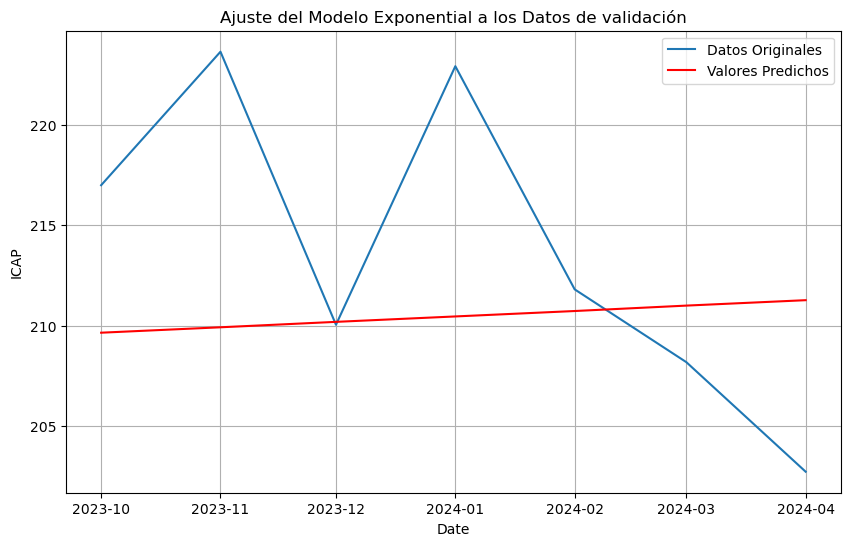

In [23]:
plt.figure(figsize=(10, 6))
plt.plot(df.index[405:], df['icap'][405:], label='Datos Originales')
plt.plot(df.index[405:], forecast_holt, label='Valores Predichos', color='red')
plt.title('Ajuste del Modelo Exponential a los Datos de validación')
plt.xlabel('Date')
plt.ylabel('ICAP')
plt.legend()
plt.grid(True)
plt.show()

In [24]:
decomposition_result = seasonal_decompose(train_data, model='additive', period=12)
estimated_trend = decomposition_result.trend.dropna()
estimated_seasonality = decomposition_result.seasonal.dropna()

In [25]:
poly = PolynomialFeatures(degree=3)
X = np.arange(len(estimated_trend)).reshape(-1, 1)
y = estimated_trend.values
X_poly = poly.fit_transform(X)

In [26]:
dates_future = pd.date_range(start='2023-10', end='2024-04', freq='MS')
X_future = np.arange(len(estimated_trend), len(estimated_trend) + len(dates_future)).reshape(-1, 1)
X_future_poly = poly.transform(X_future)

In [27]:
trend_model = LinearRegression()
trend_model.fit(X_poly, y)
predicted_poly_trend = trend_model.predict(X_future_poly)

In [28]:
future_seasonality = estimated_seasonality[-12:].head(len(dates_future)).values
complete_poly_trend_pred = predicted_poly_trend + future_seasonality
complete_poly_trend_pred_pd = pd.Series(complete_poly_trend_pred, index=dates_future)

In [29]:
complete_poly_trend_pred_pd

2023-10-01    210.993930
2023-11-01    216.514706
2023-12-01    211.239966
2024-01-01    215.374411
2024-02-01    208.373221
2024-03-01    208.069255
2024-04-01    210.359423
Freq: MS, dtype: float64

In [30]:
mse_poly_trend = mean_squared_error(val_data, complete_poly_trend_pred_pd)
mse_poly_trend

30.666146904938778

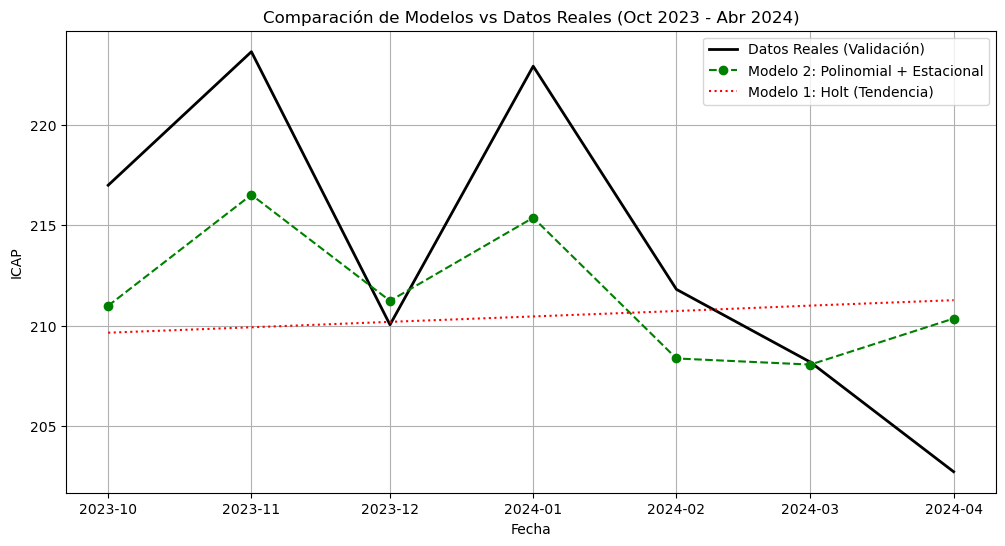

In [31]:
plt.figure(figsize=(12, 6))

# 1. Graficar los datos reales del periodo de validación (últimos meses)
plt.plot(df.index[405:], df['icap'][405:], label='Datos Reales (Validación)', color='black', linewidth=2)

# 2. Graficar la predicción del Modelo 2 (Polinomial + Estacional)
plt.plot(dates_future, complete_poly_trend_pred_pd, label='Modelo 2: Polinomial + Estacional', color='green', linestyle='--', marker='o')

# 3. Graficar la predicción del Modelo 1 (Holt) para comparar
plt.plot(df.index[405:], forecast_holt, label='Modelo 1: Holt (Tendencia)', color='red', linestyle=':')

plt.title('Comparación de Modelos vs Datos Reales (Oct 2023 - Abr 2024)')
plt.xlabel('Fecha')
plt.ylabel('ICAP')
plt.legend()
plt.grid(True)
plt.show()
